# 13. Exploring the unified data (EDA before feature engineering)

**Question.** What does the data we now hold look like as a whole (the IQVIA monthly series, the segment panel and the outside series on their availability dates), and what does that suggest we should and should not try in feature engineering and modelling?

**Answer in one line.** See the last section; it is written after the numbers below.

**Rules for this notebook.** It is **descriptive**. No hypothesis is tested, no threshold is applied, no model is fitted, and nothing here changes a result already reported. Anything that looks like a pattern is a *candidate* to test later under a rule written down first (as in the protocol); it is not a finding. The only pre-registered item inside it is **E6** (Zilretta against the hyaluronic injectables, descriptive tables, no pass or fail), section 6.

**Reproducible from committed files only:** the published warehouse, the public subset (`data/published/external_subset.db`), the availability rules and the download manifest. The outside series are built in memory with the same code the pipeline uses.

In [1]:
import json
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine
from statsmodels.tsa.stattools import acf

ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))
from oa_market_intelligence.availability import load_availability
from oa_market_intelligence.mart import build_as_of_table, build_signals, load_manifest_rows

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

wh = sqlite3.connect(ROOT / "data" / "published" / "warehouse.db")
ext = sqlite3.connect(ROOT / "data" / "published" / "external_subset.db")
q = lambda sql, con=wh: pd.read_sql(sql, con)

gold = q("select * from gold_visit_share_monthly order by month_id")
gold["date"] = pd.to_datetime(gold.month_id.astype(str), format="%Y%m")
gold["share_pct"] = gold.visit_share * 100
gold["total"] = gold.branded_injectable_visits + gold.generic_corticosteroid_visits + gold.nsaid_otc_visits
print(f"{len(gold)} months, {gold.month_id.min()} to {gold.month_id.max()}")
gold[["month_id", "branded_injectable_visits", "generic_corticosteroid_visits", "nsaid_otc_visits", "share_pct"]].describe().round(2)

72 months, 201908 to 202507


,month_id,branded_injectable_visits,generic_corticosteroid_visits,nsaid_otc_visits,share_pct
count,72.00,72.00,72.00,72.00,72.00
mean,202214.83,1876.65,68123.57,5473.28,2.47
std,178.21,507.25,10290.66,1049.57,0.44
min,201908.00,937.00,28795.00,1033.00,1.74
25%,202101.75,1389.25,60941.00,4977.75,2.04
50%,202207.50,1876.00,68343.00,5609.00,2.53
75%,202401.25,2306.25,75295.75,6147.25,2.79
max,202507.00,2849.00,89190.00,7180.00,3.38


## 1. The target series: Zilretta's share of visits

*Share* = Zilretta visits over Zilretta, generic corticosteroid injection and NSAID visits together (the definition used throughout).

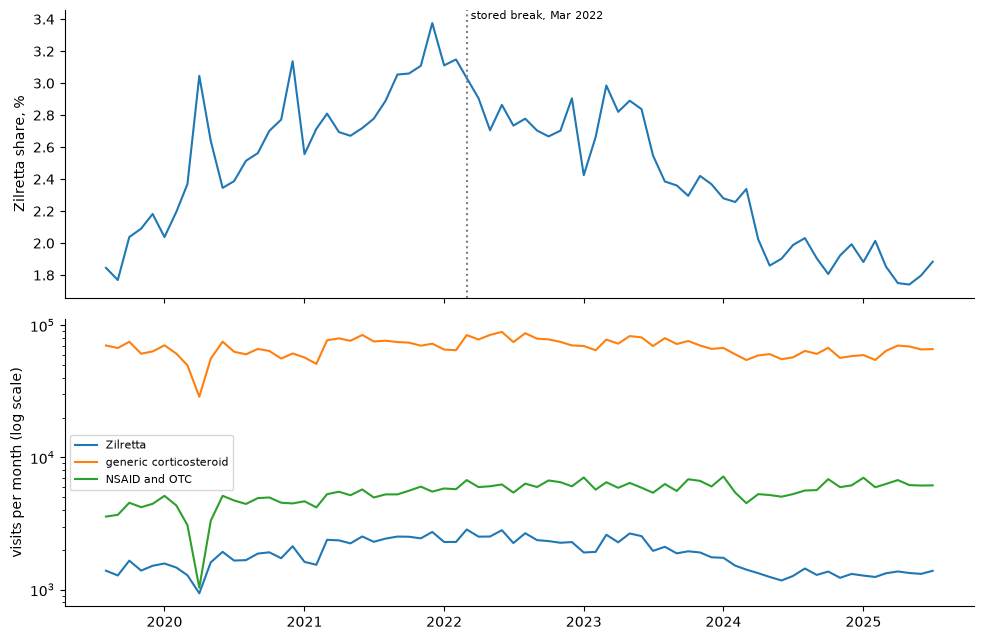

,level,monthly change (pp)
count,72.000,71.000
mean,2.466,0.001
std,0.435,0.194
min,1.741,-0.581
25%,2.036,-0.113
50%,2.531,0.042
75%,2.786,0.104
max,3.376,0.677


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(gold.date, gold.share_pct, color="#1f77b4")
axes[0].set_ylabel("Zilretta share, %")
axes[0].axvline(pd.Timestamp("2022-03-01"), color="gray", ls=":")
axes[0].text(pd.Timestamp("2022-03-01"), axes[0].get_ylim()[1], " stored break, Mar 2022", va="top", fontsize=8)
for col, label, color in [("branded_injectable_visits", "Zilretta", "#1f77b4"), ("generic_corticosteroid_visits", "generic corticosteroid", "#ff7f0e"), ("nsaid_otc_visits", "NSAID and OTC", "#2ca02c")]:
    axes[1].plot(gold.date, gold[col], label=label, color=color)
axes[1].set_yscale("log")
axes[1].set_ylabel("visits per month (log scale)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
summary = pd.DataFrame(
    {
        "level": gold.share_pct.describe(),
        "monthly change (pp)": gold.share_pct.diff().describe(),
    }
).round(3)
summary

**Reading.** The share ranges from 1.74% to 3.38% (mean 2.47%): it climbs through 2020 and 2021 to its peak of 3.38% in December 2021, then falls, to about 1.9% by July 2025. Month to month it moves by about 0.19 points (standard deviation), with extremes of -0.58 and +0.68 points. The numerator is small (about 940 to 2,850 Zilretta visits a month, against about 68,000 corticosteroid and 5,500 NSAID visits), so some of the month-to-month movement is count noise. Zilretta visits and the share both fall from 2022.

## 2. Seasonality and persistence

Descriptive only: the month-of-year profile after removing a centred 12-month average (so the trend and the 2022 turn do not masquerade as seasonality), and the autocorrelation of the share and of its monthly changes. Twelve points per calendar month at most (six for some), so these are pictures, not estimates with intervals.

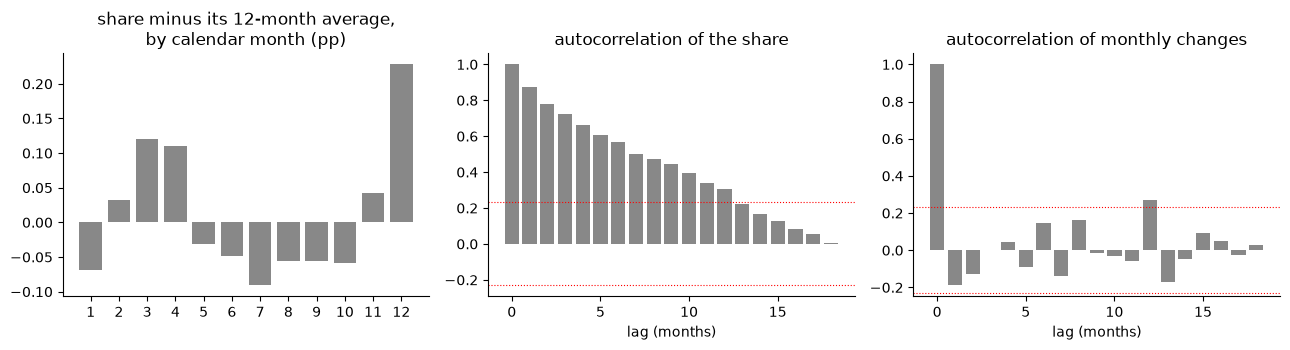

autocorrelation of the share at lags 1, 2, 3, 6, 12: {1: 0.88, 2: 0.78, 3: 0.72, 6: 0.57, 12: 0.3}
autocorrelation of monthly changes at lags 1, 2, 3, 6, 12: {1: -0.19, 2: -0.13, 3: 0.0, 6: 0.15, 12: 0.27}
dotted lines: +/- 0.23 (a rough guide, not a test)


,mean,std,count
calendar month,,,
1,-0.068,0.172,5
2,0.033,0.095,6
3,0.121,0.097,5
4,0.110,0.333,5
5,-0.031,0.239,5
6,-0.048,0.152,5
7,-0.091,0.058,5
8,-0.056,0.085,5
9,-0.056,0.101,5


In [3]:
s = gold.set_index("date").share_pct
detrended = (s - s.rolling(12, center=True).mean()).dropna()
profile = detrended.groupby(detrended.index.month).agg(["mean", "std", "count"]).round(3)
profile.index.name = "calendar month"
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].bar(profile.index, profile["mean"], color="#888")
axes[0].set_title("share minus its 12-month average,\nby calendar month (pp)")
axes[0].set_xticks(range(1, 13))
levels = acf(s, nlags=18, fft=False)
changes = acf(s.diff().dropna(), nlags=18, fft=False)
band = 1.96 / np.sqrt(len(s))
for ax, values, title in ((axes[1], levels, "autocorrelation of the share"), (axes[2], changes, "autocorrelation of monthly changes")):
    ax.bar(range(len(values)), values, color="#888")
    ax.axhline(band, color="r", ls=":", lw=0.8)
    ax.axhline(-band, color="r", ls=":", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("lag (months)")
plt.tight_layout()
plt.show()
print("autocorrelation of the share at lags 1, 2, 3, 6, 12:", {k: round(float(levels[k]), 2) for k in (1, 2, 3, 6, 12)})
print("autocorrelation of monthly changes at lags 1, 2, 3, 6, 12:", {k: round(float(changes[k]), 2) for k in (1, 2, 3, 6, 12)})
print("dotted lines: +/-", round(float(band), 2), "(a rough guide, not a test)")
profile

**Reading.** The share is highly persistent: its autocorrelation is 0.88 at one month, 0.57 at six and 0.30 at twelve. That slow decay mostly reflects the trend and the 2022 turn (a series with one regime change looks persistent whether or not it is predictable), so it is not evidence of a stable cycle. The monthly *changes* are different: their autocorrelation is -0.19 at one month (a mild pull back after a move, inside the rough guide) and +0.27 at twelve months (just outside the guide), a hint of an annual pattern. The calendar-month picture agrees in direction: December is highest (+0.23 points above the 12-month average), then March (+0.12) and April (+0.11), and July is lowest (-0.09). There are only five or six observations per calendar month, so this is a picture to test later, not an estimate. It is consistent with the seasonal rule being the best of the simple baselines in Phase 4.

## 3. What changes month to month

The distribution of monthly changes in the share, by calendar year; what a "Flat" band would have to be to be useful is a modelling question and is not decided here.

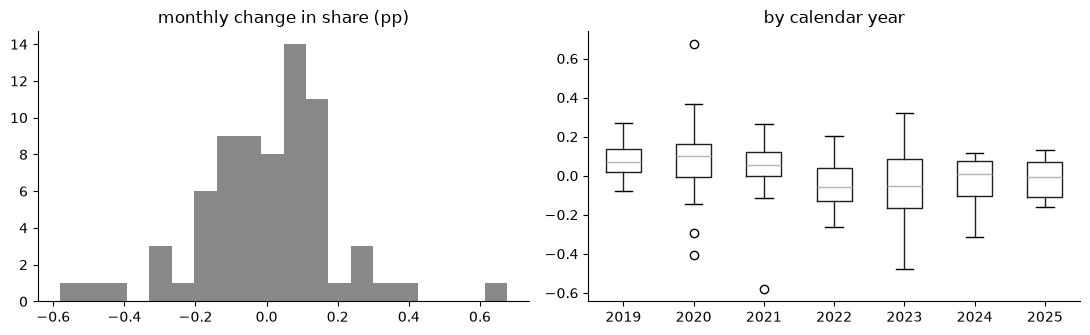

,count,mean,std,min,max
year,,,,,
2019,4,0.084,0.142,-0.076,0.268
2020,12,0.080,0.284,-0.407,0.677
2021,12,0.020,0.213,-0.581,0.267
2022,12,-0.039,0.140,-0.265,0.202
2023,12,-0.045,0.221,-0.480,0.322
2024,12,-0.031,0.129,-0.315,0.116
2025,7,-0.016,0.112,-0.161,0.132


In [4]:
chg = gold.assign(change=gold.share_pct.diff(), year=gold.date.dt.year).dropna(subset=["change"])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(chg.change, bins=20, color="#888")
axes[0].set_title("monthly change in share (pp)")
chg.boxplot(column="change", by="year", ax=axes[1], grid=False)
axes[1].set_title("by calendar year")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()
chg.groupby("year").change.agg(["count", "mean", "std", "min", "max"]).round(3)

**Reading.** The size of monthly moves changed over time. They were largest in 2020 (standard deviation 0.28 points, with the COVID months) and 2021 (0.21), smaller in 2022 (0.14), larger again in 2023 (0.22), and smallest from 2024 (0.13) and 2025 (0.11). Their average sign flips: positive in 2019 to 2021 (+0.08, +0.08, +0.02 points a month) and negative from 2022 (-0.04, -0.05, -0.03, -0.02). A fixed band for "Flat" would therefore mean different things in different years, which is why Phase 4 used a volatility-scaled band.

## 4. The segment panel (specialty x age x gender x month)

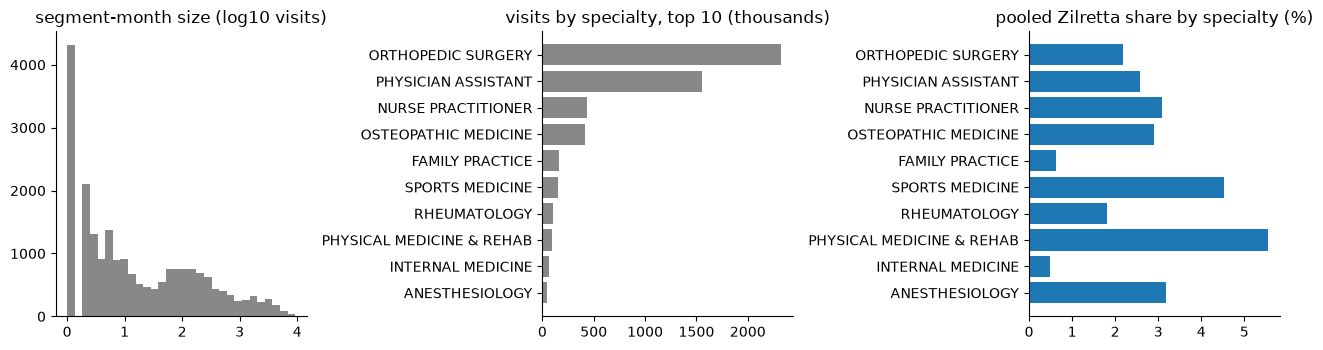

,value
segment-months,21636
distinct segments,634
share of segment-months below 20 visits,0.599
segment-months with no Zilretta visit,0.654
median visits per segment-month,8.0
segments active per month (min to max),252 to 331


,visits,z,share_pct
specialty_name,,,
ORTHOPEDIC SURGERY,2326898,50865,2.19
PHYSICIAN ASSISTANT,1553631,40171,2.59
NURSE PRACTITIONER,434256,13375,3.08
OSTEOPATHIC MEDICINE,414381,12018,2.90
FAMILY PRACTICE,159203,1009,0.63
SPORTS MEDICINE,152539,6899,4.52
RHEUMATOLOGY,99713,1807,1.81
PHYSICAL MEDICINE & REHAB,96826,5375,5.55
INTERNAL MEDICINE,62872,311,0.49


In [5]:
seg = q("select g.*, s.specialty_name, d.age_band, d.gender from gold_segment_adoption g join dim_specialty s using(specialty_id) join dim_demographics d using(demographic_id)")
MIN_VISITS = 20  # the segment feature code's small-sample floor (features/segment.py)
seg["small"] = seg.total_category_visits < MIN_VISITS
per_month = seg.groupby("month_id").agg(segments=("segment_visit_share", "size"), visits=("total_category_visits", "sum"))
facts = pd.Series(
    {
        "segment-months": len(seg),
        "distinct segments": seg[["specialty_id", "demographic_id"]].drop_duplicates().shape[0],
        f"share of segment-months below {MIN_VISITS} visits": round(seg.small.mean(), 3),
        "segment-months with no Zilretta visit": round((seg.branded_injectable_visits == 0).mean(), 3),
        "median visits per segment-month": float(seg.total_category_visits.median()),
        "segments active per month (min to max)": f"{per_month.segments.min()} to {per_month.segments.max()}",
    }
)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
axes[0].hist(np.log10(seg.total_category_visits.clip(lower=1)), bins=30, color="#888")
axes[0].set_title("segment-month size (log10 visits)")
spec = seg.groupby("specialty_name").agg(visits=("total_category_visits", "sum"), z=("branded_injectable_visits", "sum"))
spec["share_pct"] = spec.z / spec.visits * 100
top = spec.sort_values("visits", ascending=False).head(10)
axes[1].barh(top.index[::-1], top.visits[::-1] / 1000, color="#888")
axes[1].set_title("visits by specialty, top 10 (thousands)")
axes[2].barh(top.index[::-1], top.share_pct[::-1], color="#1f77b4")
axes[2].set_title("pooled Zilretta share by specialty (%)")
plt.tight_layout()
plt.show()
display(facts.to_frame("value"))
top.round(2)

**Reading.** The segment panel is large but sparse. There are 21,636 segment-months over 634 distinct segments (252 to 331 active each month). **About 60% of segment-months have fewer than 20 visits, about 65% have no Zilretta visit at all, and the median segment-month has 8 visits.** A single segment's monthly share is therefore mostly small-sample noise, which is what the Phase 4 segment estimator (blending a segment's own history with its specialty's) was built for. Pooled over all months, Zilretta's share ranges from about 5.6% in physical medicine and rehabilitation and 4.5% in sports medicine down to about 0.5% in internal medicine and 0.6% in family practice, and the two biggest specialties by visits (orthopedic surgery and physician assistants) sit near the market average (2.2% and 2.6%).

## 5. The outside series on their availability dates

Built in memory with the pipeline's own code: each series with the month it became known (R1 rules), and what would be known as of each IQVIA month (one month earlier). Plots show the series against the share for orientation only; no relationship is tested here.

In [6]:
availability = load_availability()
manifest = load_manifest_rows(ROOT / "data" / "reference" / "external_manifest.jsonl")
subset_engine = create_engine(f"sqlite:///{(ROOT / 'data' / 'published' / 'external_subset.db').resolve().as_posix()}")
signals = build_signals(subset_engine, availability, manifest)
months = gold.month_id.tolist()
asof = build_as_of_table(signals, months)
cover = (
    asof.groupby("signal_id")
    .agg(months_with_value=("month_id", "nunique"), average_age_months=("age_months", "mean"), oldest_age=("age_months", "max"))
    .round(1)
)
cover["first_month_with_value"] = asof.groupby("signal_id").month_id.min()
cover["rule"] = signals.drop_duplicates("signal_id").set_index("signal_id").source_id
cover.sort_values("months_with_value", ascending=False)

,months_with_value,average_age_months,oldest_age,first_month_with_value,rule
signal_id,,,,,
asp.j3301_limit_per_mg,72,-1.0,0,201908,asp_price
asp.j3304_limit_per_mg,72,-1.0,0,201908,asp_price
asp.price_ratio,72,-1.0,0,201908,asp_price
company.net_sales_usd,72,3.0,5,201908,sec_filings
event.count_in_month,72,8.6,26,201908,events
openpay.total_amount_usd,61,11.4,17,202007,openpay
openpay.physicians_paid,61,11.4,17,202007,openpay
openpay.n_records,61,11.4,17,202007,openpay
openpay.practitioners_paid,37,11.4,17,202207,openpay


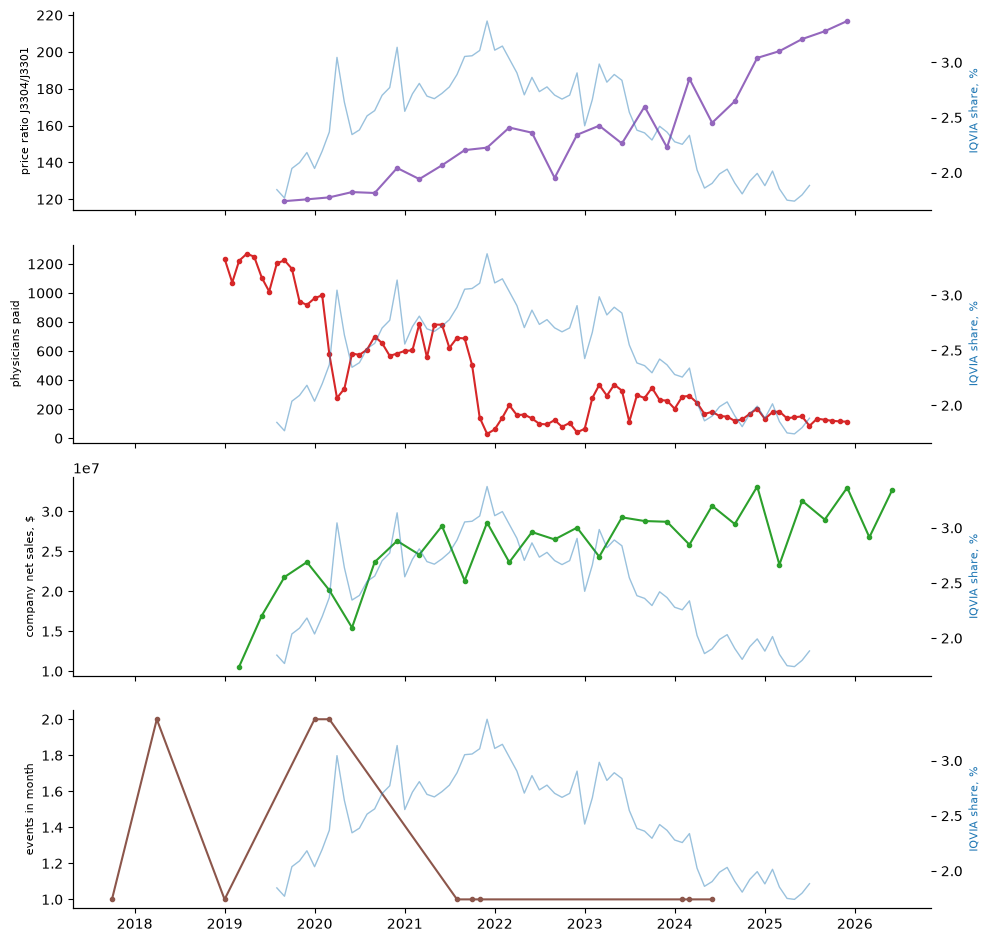

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9.5), sharex=True)
def line(ax, signal_id, label, color, group=""):
    part = signals[(signals.signal_id == signal_id) & (signals.specialty_group == group)].copy()
    part["date"] = pd.to_datetime(part.period_end_month.astype(str), format="%Y%m")
    ax.plot(part.date, part.value, "o-", ms=3, color=color, label=label)
    ax.set_ylabel(label, fontsize=8)
for ax, (sid, label, color) in zip(axes, [("asp.price_ratio", "price ratio J3304/J3301", "#9467bd"), ("openpay.physicians_paid", "physicians paid", "#d62728"), ("company.net_sales_usd", "company net sales, $", "#2ca02c"), ("event.count_in_month", "events in month", "#8c564b")]):
    line(ax, sid, label, color)
    twin = ax.twinx()
    twin.plot(gold.date, gold.share_pct, color="#1f77b4", alpha=0.45, lw=1)
    twin.set_ylabel("IQVIA share, %", fontsize=8, color="#1f77b4")
plt.tight_layout()
plt.show()

**Reading.** Only some outside series are available when a model would need them. For every one of the 72 IQVIA months a value is known for the **price series** (a month ahead, since the schedule is posted before the quarter), **company net sales** (3 months old on average, from the filing date) and **events** (14 dated events, so the series is sparse). **Promotion** (Open Payments) is known from July 2020 only, at an average age of about 11 months, and **Medicare adoption by specialty** from January 2023 only, at about 29 months. The plots are for orientation and test nothing: the J3304-to-J3301 price ratio drifts upward over the period (mostly because the comparator's limit falls); the number of physicians paid falls from about 1,200 a month to about 100, with a sharp drop in November 2021; quarterly company sales rise to about $30 to 33 million. Events are too sparse to say anything.

## 6. E6 (pre-registered, descriptive): Zilretta against the hyaluronic injectables in Medicare

Original Medicare patients, services and the number of billing providers by year, from the national rows of the Part B geography file, for Zilretta (J3304) and each hyaluronic acid code. Patients and providers are **per code and summed over the office and facility settings** (a patient seen in both settings, or treated with two products, is counted more than once), so codes are not added together. No pass or fail; it describes position, not cause. Company net sales for Zilretta (national, all payers) are shown beside it.

In [8]:
geo = q(
    "select g.year, g.hcpcs_code, g.setting, g.n_providers, g.benes, g.services, d.short_description, d.drug_family "
    "from fact_ext_partb_geo g join dim_hcpcs_code d on d.hcpcs_code = g.hcpcs_code "
    "where g.geo_level = 'National' and (g.hcpcs_code = 'J3304' or d.drug_family = 'hyaluronic_acid')",
    ext,
)
by_code = geo.groupby(["hcpcs_code", "year"]).agg(providers=("n_providers", "sum"), patients=("benes", "sum"), services=("services", "sum")).reset_index()
desc = geo.drop_duplicates("hcpcs_code").set_index("hcpcs_code").short_description
last = by_code[by_code.year == 2024].set_index("hcpcs_code")
order = last.sort_values("patients", ascending=False).index.tolist()
if "J3304" not in order[:6]:
    order = ["J3304"] + [c for c in order if c != "J3304"]
shown = list(dict.fromkeys(["J3304"] + order))[:7]
def table(metric):
    t = by_code[by_code.hcpcs_code.isin(shown)].pivot(index="hcpcs_code", columns="year", values=metric).reindex(shown)
    t.insert(0, "description", desc.reindex(shown).str.slice(0, 38))
    return t
for metric in ("patients", "providers", "services"):
    print(metric.upper(), "(Medicare, per code, office plus facility)")
    display(table(metric))

PATIENTS (Medicare, per code, office plus facility)


year,description,2019,2020,2021,2022,2023,2024
hcpcs_code,,,,,,,
J3304,"Injection, triamcinolone acetonide, pr",36493,43610,53379,51066,49620,47188
J7323,"Hyaluronan or derivative, euflexxa, fo",86904,66765,70886,73761,75394,70203
J7325,"Hyaluronan or derivative, synvisc or s",98940,70256,71322,68962,69022,65443
J7326,"Hyaluronan or derivative, gel-one, for",54310,66771,89067,82778,66991,62638
J7327,"Hyaluronan or derivative, monovisc, fo",57963,40042,40223,49926,54673,60099
J7318,"Hyaluronan or derivative, durolane, fo",19708,26532,35884,41898,48044,57143
J7321,"Hyaluronan or derivative, hyalgan, sup",79307,49173,45281,47794,55181,54924


PROVIDERS (Medicare, per code, office plus facility)


year,description,2019,2020,2021,2022,2023,2024
hcpcs_code,,,,,,,
J3304,"Injection, triamcinolone acetonide, pr",4704,5001,5449,5321,5167,4883
J7323,"Hyaluronan or derivative, euflexxa, fo",10361,9360,9603,9887,10050,9592
J7325,"Hyaluronan or derivative, synvisc or s",13426,11585,11693,11575,11243,10906
J7326,"Hyaluronan or derivative, gel-one, for",5077,5693,6602,6714,5983,5597
J7327,"Hyaluronan or derivative, monovisc, fo",5937,5318,5210,5908,6044,6215
J7318,"Hyaluronan or derivative, durolane, fo",2826,3684,4727,6132,6766,7513
J7321,"Hyaluronan or derivative, hyalgan, sup",9431,7886,7454,7385,7317,7025


SERVICES (Medicare, per code, office plus facility)


year,description,2019,2020,2021,2022,2023,2024
hcpcs_code,,,,,,,
J3304,"Injection, triamcinolone acetonide, pr",1909246.6,2646991.4,3372350.5,3424884.2,3431175.2,3434301.6
J7323,"Hyaluronan or derivative, euflexxa, fo",393605.0,302363.0,328214.0,338533.0,346795.2,322725.0
J7325,"Hyaluronan or derivative, synvisc or s",7152868.1,5083302.3,5200110.6,5016996.3,5109897.4,4867892.0
J7326,"Hyaluronan or derivative, gel-one, for",80574.0,101837.0,139811.0,128268.0,106975.0,101420.0
J7327,"Hyaluronan or derivative, monovisc, fo",89311.0,62860.3,64622.0,78769.0,88209.0,97847.0
J7318,"Hyaluronan or derivative, durolane, fo",1602816.5,2337890.0,3210507.0,3686747.9,4357243.0,5274884.0
J7321,"Hyaluronan or derivative, hyalgan, sup",461493.5,274684.0,256976.0,267714.0,318012.5,321248.0


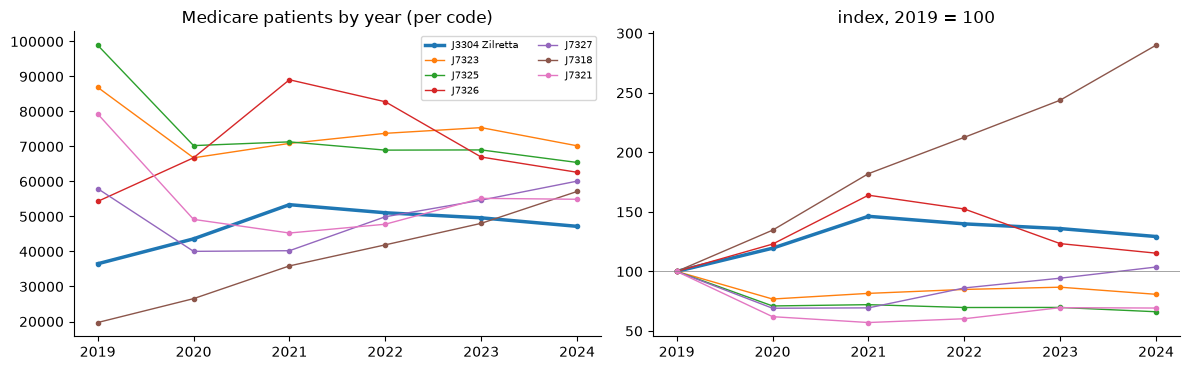

year,2018,2019,2020,2021,2022,2023,2024,2025
net_sales_million,22.5,73.0,85.6,102.7,105.5,111.1,118.1,116.6


In [9]:
patients = by_code[by_code.hcpcs_code.isin(shown)].pivot(index="year", columns="hcpcs_code", values="patients")[shown]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for code_ in shown:
    axes[0].plot(patients.index, patients[code_], "o-", ms=3, lw=2.5 if code_ == "J3304" else 1, label=f"{code_}" + (" Zilretta" if code_ == "J3304" else ""))
axes[0].set_title("Medicare patients by year (per code)")
axes[0].legend(fontsize=7, ncol=2)
index = patients / patients.loc[2019] * 100
for code_ in shown:
    axes[1].plot(index.index, index[code_], "o-", ms=3, lw=2.5 if code_ == "J3304" else 1)
axes[1].axhline(100, color="gray", lw=0.5)
axes[1].set_title("index, 2019 = 100")
plt.tight_layout()
plt.show()
revenue = q("select period_end, net_sales_usd from fact_ext_company_revenue where period_type = 'year' and product = 'Zilretta' order by period_end", ext)
revenue["year"] = revenue.period_end.str[:4]
revenue.assign(net_sales_million=(revenue.net_sales_usd / 1e6).round(1))[["year", "net_sales_million"]].set_index("year").T

**Reading (E6, descriptive).** Zilretta's Medicare patients rose from about 36,500 in 2019 to 53,400 in 2021 and have eased since to 47,200 in 2024 (about 12% below the peak); billing providers followed the same shape (4,700, 5,400, then 4,900). Its billed services, however, stayed flat from 2022 (about 3.4 million units a year) even as patients eased, so the units per patient rose. The hyaluronic injectables do not move as one: Durolane (J7318) grew almost threefold in patients (19,700 to 57,100), Monovisc (J7327) recovered to its 2019 level, Gel-One (J7326) peaked in 2021 and eased, while Synvisc (J7325), Hyalgan (J7321) and Euflexxa (J7323) fell in 2020 and have stayed below their 2019 level. Zilretta did *not* dip in 2020, when most hyaluronic codes did. Company net sales rose from $73.0 million (2019) to $118.1 million (2024). **Caution:** services are billing units and the unit differs by code (per milligram for Zilretta, per dose for the hyaluronic products), so services are only comparable within a code over time; patients and providers are summed over the office and facility settings and are per code. This describes position, not cause.

## 7. Data issues that any model has to live with

In [10]:
issues = pd.DataFrame(
    [
        ("COVID months", "202003 to 202005", "visits fall sharply; flagged in the feature code"),
        ("early-2024 dip", "202403 to 202407", "all three IQVIA categories fall; kept and flagged; Zilretta fell about twice as much as the others (notebook 12)"),
        ("2025 is partial", "202501 to 202507", "seven months; no full year after 2024"),
        ("IQVIA starts mid-2019", "201908", "five months in 2019; the first full year is 2020"),
        ("one regime change", "202203 (stored break)", "a level and trend shift; models trained across it see two regimes"),
        ("history is short", "72 months", "limits what any national-series result can show (power statement, DL-56)"),
    ],
    columns=["issue", "months", "note"],
)
issues

,issue,months,note
0,COVID months,202003 to 202005,visits fall sharply; flagged in the feature code
1,early-2024 dip,202403 to 202407,all three IQVIA categories fall; kept and flag...
2,2025 is partial,202501 to 202507,seven months; no full year after 2024
3,IQVIA starts mid-2019,201908,five months in 2019; the first full year is 2020
4,one regime change,202203 (stored break),a level and trend shift; models trained across...
5,history is short,72 months,limits what any national-series result can sho...


## 8. What this suggests (candidates only, none tested)

Nothing below is a finding. These are things to **decide on, and test under a rule written down first**, in feature engineering and modelling:

| Observation | Candidate for later (pre-registered if tested) |
|---|---|
| Annual hint in the changes (lag-12 autocorrelation +0.27; December and March to April high) | Month-of-year as a feature; the seasonal rule already does this, so the question is whether anything beats it |
| The share is very persistent and monthly changes pull back slightly (lag-1 -0.19) | "Same as last month" will be hard to beat (consistent with Phase 4); test combinations of it with other forecasts |
| 60% of segment-months have fewer than 20 visits and 65% have no Zilretta visit | Partial pooling and count models for the segment estimator; more data per cell is not available |
| Only price and company sales are known for all 72 months; promotion starts July 2020 and Medicare adoption January 2023, both heavily lagged | A very short list of outside features (price ratio, company sales with their 3-month lag, events); expect small effects |
| The injectable market is not moving as one (Durolane tripled, Synvisc fell, Zilretta rose then eased; Zilretta did not dip in 2020) | A competitor-specific share (Zilretta against its closest substitutes) is worth a look, and Durolane is the one competitor that stands out; IQVIA has no hyaluronic products, so this can only be seen in Medicare |
| Sizes of monthly moves differ by year (0.28 points in 2020 to 0.11 in 2025) | Volatility-scaled labels and intervals (already used), recency weighting |
| The 2020 COVID months and the early-2024 dip | Treat as flagged months; test whether handling the 2024 dip changes the forecasts after it |

**What this does not change:** any reported result, any threshold, or the conclusion that the national series is too short to show a small gain. The three limits (72 months, one regime change, no monthly drivers) are visible in these pictures.